#Loading the Dataset and the Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df=pd.read_csv("Goa_Beach.csv")

In [40]:
df.shape

(1461, 46)

In [41]:
df.head()

,date,year,month,month_name,day_of_week,day_of_week_num,is_weekend,quarter,day_of_year,is_monsoon,...,is_major_festival_or_event_lag1,is_major_festival_or_event_lag2,is_holiday_or_weekend_lag1,is_holiday_or_weekend_lag2,is_carnaval_lag1,is_carnaval_lag2,is_shigmo_lag1,is_shigmo_lag2,is_sao_joao_lag1,is_sao_joao_lag2
0,01-01-2022,2022,1,January,Saturday,5,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,02-01-2022,2022,1,January,Sunday,6,1,1,2,0,...,0,0,1,0,0,0,0,0,0,0
2,03-01-2022,2022,1,January,Monday,0,0,1,3,0,...,0,0,1,1,0,0,0,0,0,0
3,04-01-2022,2022,1,January,Tuesday,1,0,1,4,0,...,0,0,0,1,0,0,0,0,0,0
4,05-01-2022,2022,1,January,Wednesday,2,0,1,5,0,...,0,0,0,0,0,0,0,0,0,0


#Data Quality check

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   date                             1461 non-null   object 
 1   year                             1461 non-null   int64  
 2   month                            1461 non-null   int64  
 3   month_name                       1461 non-null   object 
 4   day_of_week                      1461 non-null   object 
 5   day_of_week_num                  1461 non-null   int64  
 6   is_weekend                       1461 non-null   int64  
 7   quarter                          1461 non-null   int64  
 8   day_of_year                      1461 non-null   int64  
 9   is_monsoon                       1461 non-null   int64  
 10  is_public_holiday                1461 non-null   int64  
 11  holiday_name                     68 non-null     object 
 12  is_holiday_or_weeken

##Checking for missing and duplicate values

In [43]:
df.isnull().sum()

,0
date,0
year,0
month,0
month_name,0
day_of_week,0
day_of_week_num,0
is_weekend,0
quarter,0
day_of_year,0
is_monsoon,0


In [44]:
df.duplicated().sum()

np.int64(0)

##Target Variable Analysis

In [45]:
df["beach_waste_daily_mt"].describe()

,beach_waste_daily_mt
count,1461.000000
mean,3.030527
std,1.266281
min,0.631000
25%,2.105000
50%,2.800000
75%,3.661000
max,11.164000


In [46]:
df["beach_waste_daily_mt"].isnull().sum()

np.int64(0)

##Wave Variable Analysis

In [47]:
print("Missing wave values:", df["wave_height_m"].isnull().sum())

print("\nIncomplete wave days:")
print(
    df.loc[
        df["wave_complete_day"] == 0,
        ["date", "wave_height_m", "valid_wave_3hour_obs"]
    ]
)

Missing wave values: 1

Incomplete wave days:
            date  wave_height_m  valid_wave_3hour_obs
1460  31-12-2025            NaN                     1


#Data Preprocessing

In [48]:
# converting date into datetime
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
print(df["date"].dtype)

datetime64[ns]


In [49]:
df = df.sort_values("date").reset_index(drop=True)

##Handling the Holiday_name column

In [50]:
df["holiday_name"] = df["holiday_name"].fillna("No Holiday")

##Filling the missing value in Wave column

In [51]:
wave_mean = df["wave_height_m"].mean()

df["wave_height_m"] = df["wave_height_m"].fillna(wave_mean)


#EDA(Exploratory Data Analysis)

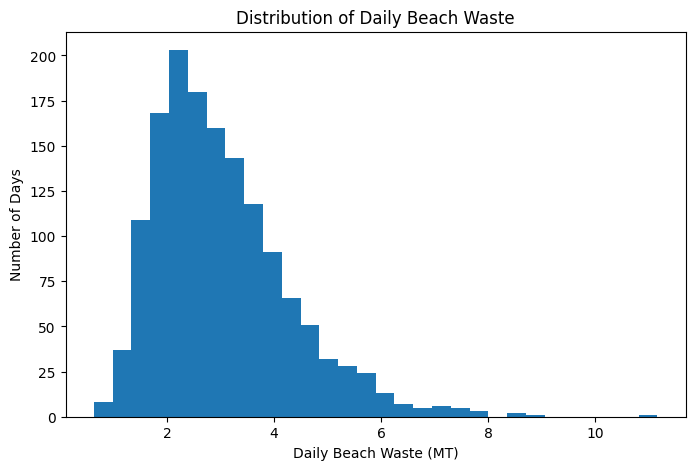

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(df["beach_waste_daily_mt"], bins=30)
plt.xlabel("Daily Beach Waste (MT)")
plt.ylabel("Number of Days")
plt.title("Distribution of Daily Beach Waste")

plt.show()

##Waste Vs Time

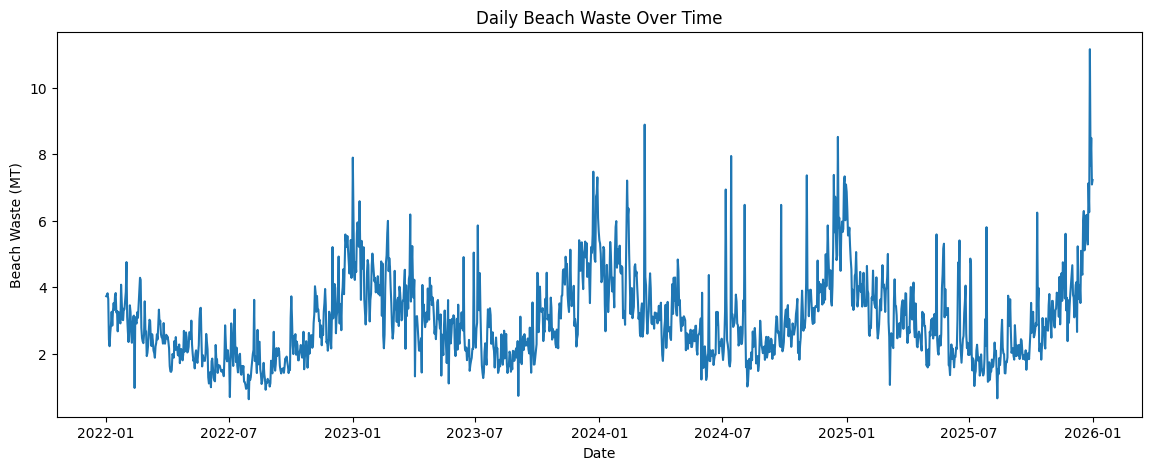

In [53]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["beach_waste_daily_mt"]
)

plt.xlabel("Date")
plt.ylabel("Beach Waste (MT)")
plt.title("Daily Beach Waste Over Time")

plt.show()

##Waste Over Different Months

Because beach activities are a lot like a seasonal activity

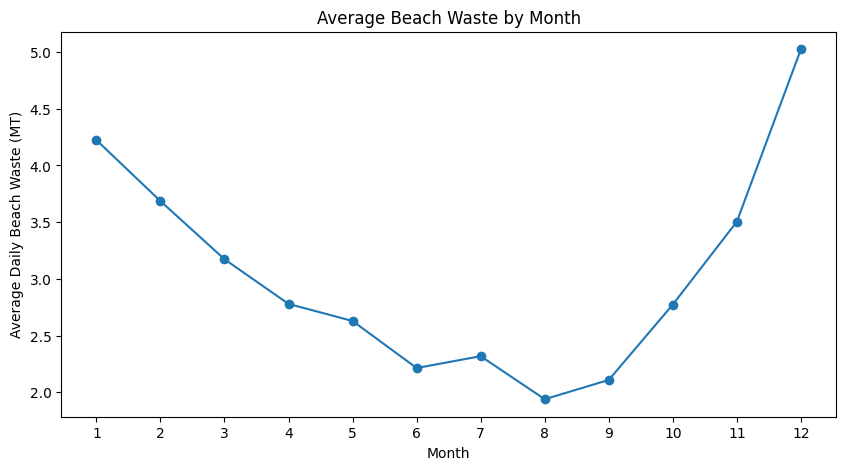

In [54]:
monthly_waste = df.groupby("month")["beach_waste_daily_mt"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_waste.index,
    monthly_waste.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Daily Beach Waste (MT)")
plt.title("Average Beach Waste by Month")
plt.xticks(range(1, 13))

plt.show()

###Observation:
--> Goa's peak tourism/beach-use season is not actually the summer months.       
--> Goa Tourism describes June–September as the monsoon, and official Goa tourism planning data shows the largest share of tourist arrivals in October–December, while July–September is the lowest quarter.

##Weekend Vs Week day

In [55]:
weekend_waste = df.groupby("is_weekend")["beach_waste_daily_mt"].mean()

Monday       3.003373
Tuesday      2.921459
Wednesday    2.930756
Thursday     2.961442
Friday       2.954413
Saturday     3.142593
Sunday       3.298957
Name: beach_waste_daily_mt, dtype: float64


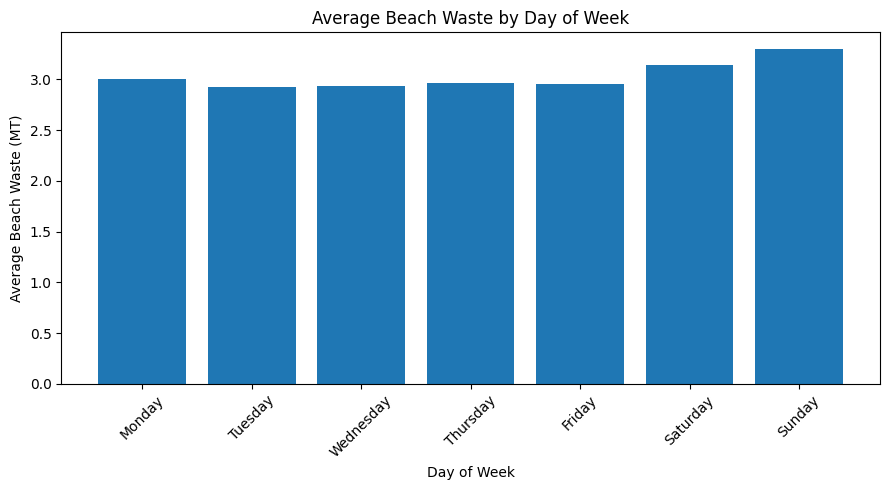

In [56]:
day_waste = df.groupby("day_of_week_num")["beach_waste_daily_mt"].mean()

day_names = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_waste.index = [day_names[i] for i in day_waste.index]

print(day_waste)

plt.figure(figsize=(9, 5))

plt.bar(day_waste.index, day_waste.values)

plt.xlabel("Day of Week")
plt.ylabel("Average Beach Waste (MT)")
plt.title("Average Beach Waste by Day of Week")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

###Observation:

--> Most of the people are free during the weekend so the beach waste is at an all time high on sunday and on Monday.

In [57]:
# checking whether weekend activity carries over to the next day

weekend_lag_waste = df.groupby(
    "is_weekend_lag1"
)["beach_waste_daily_mt"].mean()

print(weekend_lag_waste)

is_weekend_lag1
0    2.982179
1    3.151165
Name: beach_waste_daily_mt, dtype: float64


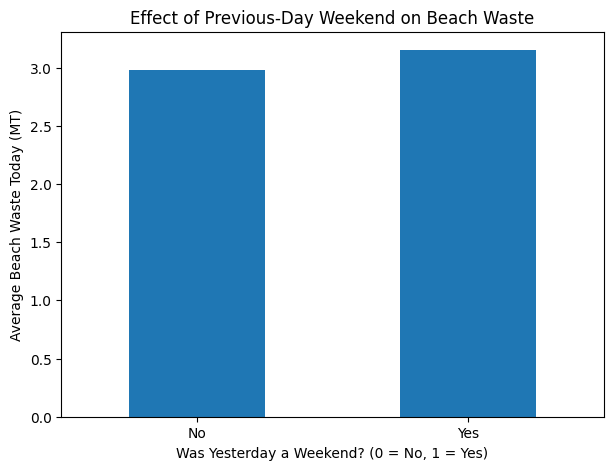

In [58]:
weekend_lag_waste.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Was Yesterday a Weekend? (0 = No, 1 = Yes)")
plt.ylabel("Average Beach Waste Today (MT)")
plt.title("Effect of Previous-Day Weekend on Beach Waste")

plt.xticks([0, 1], ["No", "Yes"], rotation=0)

plt.show()

##Waste Vs Festival

In [59]:
festival_lag_waste = df.groupby(
    "is_major_festival_or_event_lag1"
)["beach_waste_daily_mt"].mean()


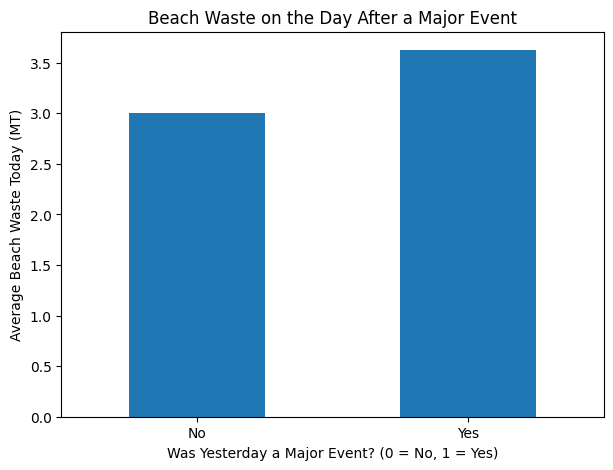

In [60]:
festival_lag_waste.plot(
    kind="bar",
    figsize=(7, 5)
)
plt.xlabel("Was Yesterday a Major Event? (0 = No, 1 = Yes)")
plt.ylabel("Average Beach Waste Today (MT)")
plt.title("Beach Waste on the Day After a Major Event")

plt.xticks([0, 1], ["No", "Yes"], rotation=0)

plt.show()

###Observation:
--> The same phenomenon is observed the next day after the festival, the waste accumulated is at an all time high.

##Correlation:

In [61]:
numeric_cols = [
    "year",
    "month",
    "day_of_week_num",
    "is_weekend",
    "is_public_holiday",
    "is_monsoon",
    "is_major_festival_or_event",
    "rainfall_mm",
    "wave_height_m",
    "wind_speed_10m_mps",
    "population_thousand",
    "domestic_tourists_annual",
    "foreign_tourists_annual",
    "total_tourists_annual",
    "beach_waste_daily_mt"
]

corr = df[numeric_cols].corr()

corr["beach_waste_daily_mt"].sort_values(ascending=False)

,beach_waste_daily_mt
beach_waste_daily_mt,1.000000
foreign_tourists_annual,0.265136
total_tourists_annual,0.214158
domestic_tourists_annual,0.206285
year,0.187499
population_thousand,0.182344
is_major_festival_or_event,0.099383
is_weekend,0.095145
day_of_week_num,0.076407
is_public_holiday,0.046711


###HeatMap

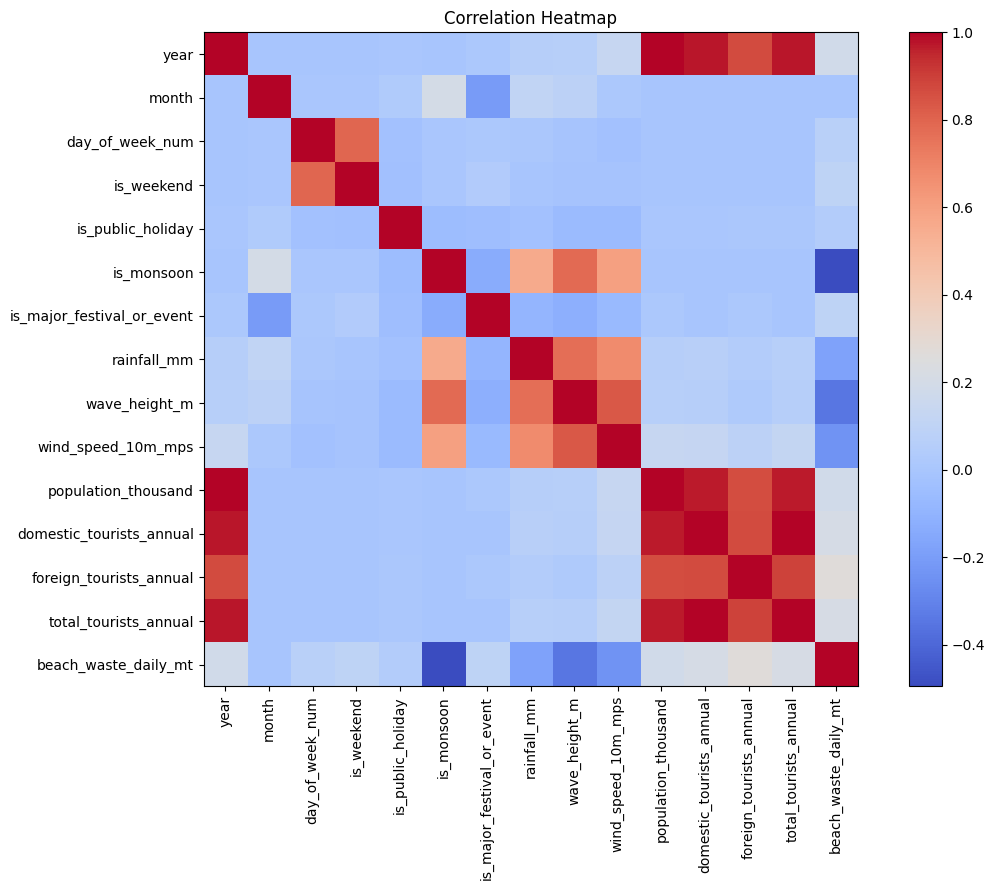

In [62]:
plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect="equal",cmap="coolwarm")
plt.colorbar()
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

##Waste collected in accordance to differnet years

In [63]:
year_waste = df.groupby("year")["beach_waste_daily_mt"].agg(
    ["mean", "min", "max"])

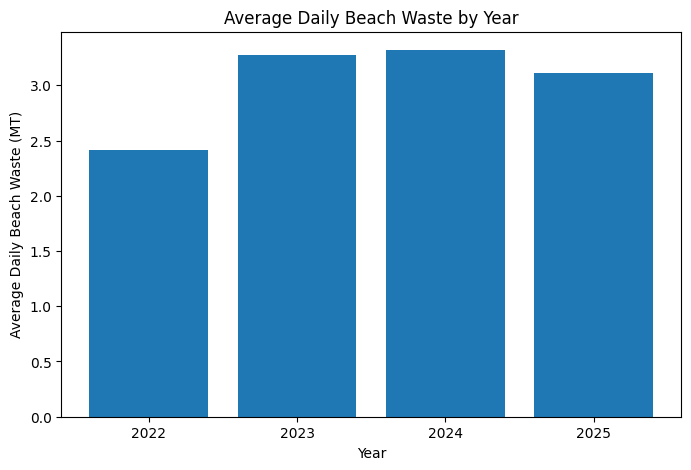

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(
    year_waste.index.astype(str),
    year_waste["mean"]
)

plt.xlabel("Year")
plt.ylabel("Average Daily Beach Waste (MT)")
plt.title("Average Daily Beach Waste by Year")

plt.show()

###Observation:
2022 has the least amount of wastes most probabaly because it was the time when people started coming ouut of lockdown

#Feature Selection

In [65]:
df.columns

Index(['date', 'year', 'month', 'month_name', 'day_of_week', 'day_of_week_num',
       'is_weekend', 'quarter', 'day_of_year', 'is_monsoon',
       'is_public_holiday', 'holiday_name', 'is_holiday_or_weekend',
       'is_carnaval', 'is_shigmo', 'is_sao_joao', 'is_tripurari_pournima',
       'is_major_festival_or_event', 'rainfall_mm', 'valid_rain_grid_cells',
       'wave_height_m', 'valid_wave_3hour_obs', 'wave_complete_day',
       'wind_speed_10m_mps', 'population_thousand', 'domestic_tourists_annual',
       'foreign_tourists_annual', 'total_tourists_annual',
       'beach_waste_daily_mt', 'rainfall_lag1', 'rainfall_lag2',
       'rainfall_3day_sum', 'is_weekend_lag1', 'is_weekend_lag2',
       'is_public_holiday_lag1', 'is_public_holiday_lag2',
       'is_major_festival_or_event_lag1', 'is_major_festival_or_event_lag2',
       'is_holiday_or_weekend_lag1', 'is_holiday_or_weekend_lag2',
       'is_carnaval_lag1', 'is_carnaval_lag2', 'is_shigmo_lag1',
       'is_shigmo_lag2', 'is_sa

##Removing Unnecessary columns with respect to our model

In [66]:
columns_drop = [
    "year",
    "month",
    "month_name",
    "day_of_week",
    "quarter",
    "day_of_year",
    "holiday_name",
    "is_holiday_or_weekend",
    "is_carnaval",
    "is_shigmo",
    "is_sao_joao",
    "is_tripurari_pournima",
    "valid_rain_grid_cells",
    "valid_wave_3hour_obs",
    "wave_complete_day",
    "domestic_tourists_annual",
    "foreign_tourists_annual",
    "rainfall_lag2",
    "is_weekend_lag2",
    "is_public_holiday_lag2",
    "is_major_festival_or_event_lag2",
    "is_holiday_or_weekend_lag1",
    "is_holiday_or_weekend_lag2",
    "is_carnaval_lag1",
    "is_carnaval_lag2",
    "is_shigmo_lag1",
    "is_shigmo_lag2",
    "is_sao_joao_lag1",
    "is_sao_joao_lag2"
]

df = df.drop(columns=columns_drop)

In [67]:
# checking the remaining columns
for i, col in enumerate(df.columns, 1):
    print(i,"", col)

1  date
2  day_of_week_num
3  is_weekend
4  is_monsoon
5  is_public_holiday
6  is_major_festival_or_event
7  rainfall_mm
8  wave_height_m
9  wind_speed_10m_mps
10  population_thousand
11  total_tourists_annual
12  beach_waste_daily_mt
13  rainfall_lag1
14  rainfall_3day_sum
15  is_weekend_lag1
16  is_public_holiday_lag1
17  is_major_festival_or_event_lag1


#Feature Engineering

In [68]:
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

df[["date", "day", "month", "year"]].head()

,date,day,month,year
0,2022-01-01,1,1,2022
1,2022-01-02,2,1,2022
2,2022-01-03,3,1,2022
3,2022-01-04,4,1,2022
4,2022-01-05,5,1,2022


In [69]:
# removing the original date column
df = df.drop(columns=["date"])


#Train_Test_Split in accordance to time-series
Splitting the Data Based on the year

##Seperating features from target column

In [70]:
target = "beach_waste_daily_mt"

X = df.drop(columns=[target])
y = df[target]

In [71]:
train = df["year"] < 2025
test = df["year"] == 2025

X_train = X.loc[train]
X_test = X.loc[test]

y_train = y.loc[train]
y_test = y.loc[test]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
X_train.columns

X_train: (1096, 18)
X_test: (365, 18)
y_train: (1096,)
y_test: (365,)


Index(['day_of_week_num', 'is_weekend', 'is_monsoon', 'is_public_holiday',
       'is_major_festival_or_event', 'rainfall_mm', 'wave_height_m',
       'wind_speed_10m_mps', 'population_thousand', 'total_tourists_annual',
       'rainfall_lag1', 'rainfall_3day_sum', 'is_weekend_lag1',
       'is_public_holiday_lag1', 'is_major_festival_or_event_lag1', 'day',
       'month', 'year'],
      dtype='object')

##Observation:
--> We are not doing the train_test_split from scikit learn because for our project, we want the model to learn from the past and then be tested on the future.    
--> We dont want the data to be in leaked.

#Training the Model

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"\n{name}")
    print(f"Training MAE : {train_mae:.4f}")
    print(f"Training RMSE : {train_rmse:.4f}")
    print(f"Training R² : {train_r2:.4f}")

    print("-" * 50)

    print(f"Test MAE : {test_mae:.4f}")
    print(f"Test RMSE : {test_rmse:.4f}")
    print(f"Test R² : {test_r2:.4f}")

    print("=" * 50)


Linear Regression
Training MAE : 0.7073
Training RMSE : 0.9684
Training R² : 0.3956
--------------------------------------------------
Test MAE : 4.1396
Test RMSE : 4.2649
Test R² : -9.4168

Decision Tree
Training MAE : 0.0000
Training RMSE : 0.0000
Training R² : 1.0000
--------------------------------------------------
Test MAE : 0.8314
Test RMSE : 1.1274
Test R² : 0.2721

Random Forest
Training MAE : 0.1748
Training RMSE : 0.2576
Training R² : 0.9572
--------------------------------------------------
Test MAE : 0.6461
Test RMSE : 0.8722
Test R² : 0.5643

Gradient Boosting
Training MAE : 0.3786
Training RMSE : 0.5348
Training R² : 0.8157
--------------------------------------------------
Test MAE : 0.6603
Test RMSE : 0.8879
Test R² : 0.5485


#Hyperparamter Tuning

In [73]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


params = {
    "Decision Tree": {
        "max_depth": [3, 5, 8, 12, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "n_estimators": [200, 400],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", 0.8]
    },

    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }
}


tscv = TimeSeriesSplit(n_splits=5)


best_models = {}


for name, model in models.items():

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params[name],
        cv=tscv,
        scoring="r2",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"\n{name}")
    print(f"Best Parameters : {grid_search.best_params_}")
    print(f"Best CV R² : {grid_search.best_score_:.4f}")

    print("-" * 50)

    print(f"Training MAE : {train_mae:.4f}")
    print(f"Training RMSE : {train_rmse:.4f}")
    print(f"Training R² : {train_r2:.4f}")

    print("-" * 50)

    print(f"Test MAE : {test_mae:.4f}")
    print(f"Test RMSE : {test_rmse:.4f}")
    print(f"Test R² : {test_r2:.4f}")

    print("=" * 50)


Decision Tree
Best Parameters : {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV R² : 0.1233
--------------------------------------------------
Training MAE : 0.6208
Training RMSE : 0.8481
Training R² : 0.5364
--------------------------------------------------
Test MAE : 0.6250
Test RMSE : 0.8911
Test R² : 0.5452

Random Forest
Best Parameters : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R² : 0.2815
--------------------------------------------------
Training MAE : 0.2914
Training RMSE : 0.4403
Training R² : 0.8751
--------------------------------------------------
Test MAE : 0.6682
Test RMSE : 0.8943
Test R² : 0.5420

Gradient Boosting
Best Parameters : {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R² : 0.2884
--------------------------------------------------
Training MAE : 0.3786
Training RMSE : 0.5348
Training R² : 0.

#Feature Importance

In [74]:
!pip install -q shap

In [77]:
import shap
model = best_models["Gradient Boosting"]

In [78]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

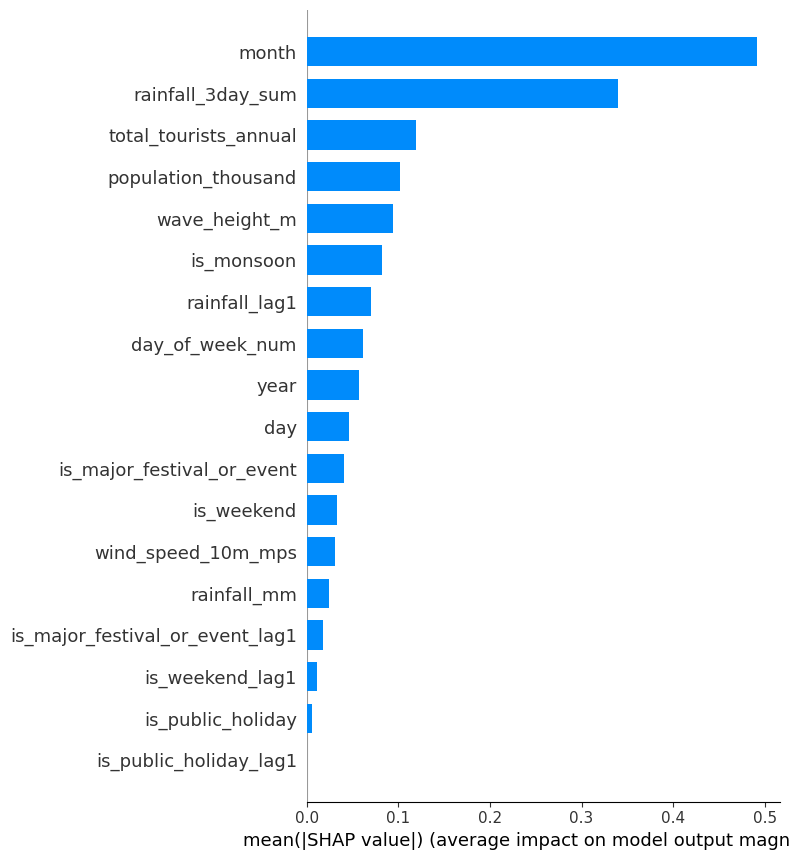

In [79]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

##Creating the table using SHAP for better Understanding

In [80]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)

feature_importance

,Feature,SHAP Importance
16,month,0.491809
11,rainfall_3day_sum,0.339939
9,total_tourists_annual,0.119634
8,population_thousand,0.101372
6,wave_height_m,0.093853
2,is_monsoon,0.082275
10,rainfall_lag1,0.070390
0,day_of_week_num,0.061217
17,year,0.056901
15,day,0.046755


#Pickling the Model

In [87]:
import pickle

final_model = best_models["Gradient Boosting"]

with open("goa_beach_waste_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

In [88]:
from google.colab import files

files.download("goa_beach_waste_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
import json

feature_names = X_train.columns.tolist()

with open("feature_names.json", "w") as file:
    json.dump(feature_names, file)

In [90]:
files.download("feature_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>